In [2]:
import pandas as pd
import numpy as np
df1 = pd.read_excel("C:/Users/ELCOT/online_retail_II.xlsx")
# ---------Data Inspection-----------
# View first 5 rows
print(df1.head())
# Check the dataset shape(rows,columns)
print(df1.shape)
# Check data types and null values
df1.info()
# Check column names
df1.columns

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
(541910, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----       

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [3]:
# ---------Column Cleaning---------
df1.columns = ['invoice','stockCode','description','quantity',
              'invoice_date','price','customer_id','country']
df1.columns

Index(['invoice', 'stockCode', 'description', 'quantity', 'invoice_date',
       'price', 'customer_id', 'country'],
      dtype='object')

In [4]:
# ---------Handling Missing Values---------
# Check missing values
df1.isnull().sum()

invoice              0
stockCode            0
description       1454
quantity             0
invoice_date         0
price                0
customer_id     135080
country              0
dtype: int64

In [5]:
# show rows where any value is missing
df1[df1.isnull().any(axis=1)].head()

,invoice,stockCode,description,quantity,invoice_date,price,customer_id,country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [6]:
''' handle description missing values
find nan and replace with  Unknown - product name not critical so we can replace with unknown - 
even if description missing we still know customer, price,quantity,date'''

df1['description'] = df1['description'].fillna('Unknown')
df1['description'].isnull().sum()

np.int64(0)

In [7]:
# Nan means not a number - in pandas it represented as a missing value
# see missing customer_id
df1[df1['customer_id'].isnull()].head()
#count missing customer_id
df1['customer_id'].isnull().sum()
# remove rows with missing customer_id
df1 = df1.dropna(subset = ['customer_id'])
# verify the count
df1['customer_id'].isnull().sum()

np.int64(0)

In [8]:
df1.dtypes

invoice                 object
stockCode               object
description             object
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id            float64
country                 object
dtype: object

In [9]:
# convert datatype
df1['customer_id'] = df1['customer_id'].astype(int)

In [10]:
# final checkup
df1.isnull().sum()

invoice         0
stockCode       0
description     0
quantity        0
invoice_date    0
price           0
customer_id     0
country         0
dtype: int64

In [11]:
# ---------Removing Duplicates---------
# check how many duplicate rows exist in the dataset
df1.duplicated().sum()
# display rows that are duplicated
df1[df1.duplicated()].head()
# remove duplicates
df1 = df1.drop_duplicates()
#verify duplicates removed
df1.duplicated().sum()
# check dataset shape
df1.shape

(401605, 8)

In [12]:
# if keep the negative quantity your rfm result will wrong ex: quantity -10 * price 5 = -50
# remove negative quantity - check negative quantity - negative means cancelled or returned 
df1[df1['quantity']< 0]
# count rows where quantity is negative(returns)
print((df1['quantity']< 0).sum())
# remove returned or cancelled orders - keep quantity > 0 removes < 0
df1 = df1[df1['quantity'] > 0]
# verify removed
print((df1['quantity']< 0).sum())
# check shape after claening
df1.shape


8872
0


(392733, 8)

In [13]:
# price = 0 indicates no revenue of free/adjustment transaction
# RFM analysis  - Recency-last purchase date,Frequency-number of purchase-requires actual monetary value - monetary = quantity * price - total spent
# remove prices where less than zero
# check invalid price
df1[df1['price'] <= 0]
# remove invalid price
df1 = df1[df1['price'] > 0]
# verify removed
print((df1['price']< 0).sum())
# check shape after claening
df1.shape


0


(392693, 8)

In [14]:
# create total amount column
df1['total_amount'] = df1['quantity'] * df1['price']
df1['total_amount'].head()

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: total_amount, dtype: float64

In [15]:
#create date features
df1['year'] = df1['invoice_date'].dt.year
df1['month'] = df1['invoice_date'].dt.month
df1['day'] = df1['invoice_date'].dt.day

In [16]:
# final dataset check
df1.info()
df1.describe()
df1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 392693 entries, 0 to 541909
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       392693 non-null  object        
 1   stockCode     392693 non-null  object        
 2   description   392693 non-null  object        
 3   quantity      392693 non-null  int64         
 4   invoice_date  392693 non-null  datetime64[ns]
 5   price         392693 non-null  float64       
 6   customer_id   392693 non-null  int64         
 7   country       392693 non-null  object        
 8   total_amount  392693 non-null  float64       
 9   year          392693 non-null  int32         
 10  month         392693 non-null  int32         
 11  day           392693 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(2), object(4)
memory usage: 34.5+ MB


,invoice,stockCode,description,quantity,invoice_date,price,customer_id,country,total_amount,year,month,day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1


In [17]:
# rfm table creation
# To calculate recency (last purchased date) - find latest date 
reference_date = df1['invoice_date'].max()

In [18]:
#Calculate recency to know how recently customer purchased
# groupby customer and find last purchased date
recency = df1.groupby('customer_id')['invoice_date'].max()
# ref_date Dec 10 - last_purchase Dec 5 = recency 5days
recency = (reference_date - recency).dt.days

In [19]:
# calculate frequency - to know how often customer purchased
# counts number of purchase
frequency = df1.groupby('customer_id')['invoice'].nunique()


In [20]:
# calculate monetory - how much customer spent
# adds total money spent by the customer
monetary = df1.groupby('customer_id')['total_amount'].sum()

In [21]:
# combine rfm table - three columns in one table
rfm = pd.concat([recency,frequency,monetary], axis=1)

In [22]:
# rename columns
rfm.columns = ['Recency','Frequency','Monetary']

In [23]:
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [24]:
#RFM score creation- without this we cant segment customers,identify best customers,identify lost customers
# Recency Score using qcut - qcut divides the values into 5 equal groups
# low recency = recent customer = better --- so labels reversed[5,4,3,2,1]
rfm['R_score'] = pd.qcut(rfm['Recency'],5, labels = [5,4,3,2,1])
#rfm['Recency'] - column used for scoring, labels = [5,4,3,2,1] - smaller recency gets higher score - result stored in R_score


In [25]:
# frequency score - higher frequency = customer buys often = better
# rank() used to avoid duplicate value error - labels normal order[1,2,3,4,5]
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method = 'first'),5, labels = [1,2,3,4,5])
#rfm['Frequency'] - purchase count, rank(method = 'first')- gives unique rank values, labels = [1,2,3,4,5] - higher frequency = higher score
# 5 divides into 5 groups


In [26]:
# monetary score   higher monetary = customer spends more = better
rfm['M_score'] = pd.qcut(rfm['Monetary'],5,labels = [1,2,3,4,5])

In [27]:
# combine r f m scores into single column - convert each score to string - concate
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str) )

In [28]:
rfm['RFM_score']
# rfm score meaning - R(how recently customer purchased)
# F(how recently customer purchased)\
# M(how much customer spent) - higher values 555 - best customers - lower values 111 = least valuable customers
#R(5-very recent,4-recent,3-medium,2-old,1-very old) F(5-frequent buyer 1- rare buyer) M(5- higher spender, 1- lower )

customer_id
12346    115
12347    555
12348    244
12349    414
12350    112
        ... 
18280    121
18281    121
18282    531
18283    554
18287    344
Name: RFM_score, Length: 4338, dtype: object

In [29]:
# Create customer segments based on R and F scores
# High R and high F → best customers
# Low R and low F → lost customers
#rfm.loc - update rows based on the condition
rfm['Segment'] = 'Others'

rfm.loc[(rfm['R_score'] >= 4) & (rfm['F_score'] >= 4), 'Segment'] = 'Champions'

rfm.loc[(rfm['R_score'] >= 3) & (rfm['F_score'] >= 3), 'Segment'] = 'Loyal Customers'

rfm.loc[(rfm['R_score'] <= 2) & (rfm['F_score'] >= 3), 'Segment'] = 'At Risk'

rfm.loc[(rfm['R_score'] == 1) & (rfm['F_score'] == 1), 'Segment'] = 'Lost Customers'


In [30]:
#check distribution
rfm['Segment'].value_counts()

Segment
At Risk            2402
Others             1371
Lost Customers      364
Loyal Customers     201
Name: count, dtype: int64

In [31]:
# segment analysis - group customers by segment and calculate average values
# helps to understand behavior of each segment - group all customers based on their segment
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,39.372606,6.641132,3255.739789
Lost Customers,277.684066,1.000000,543.422692
Loyal Customers,236.313433,3.000000,1205.422488
Others,112.280088,1.176513,457.216734


In [32]:
# count customers in each segment
rfm['Segment'].value_counts()

Segment
At Risk            2402
Others             1371
Lost Customers      364
Loyal Customers     201
Name: count, dtype: int64

In [33]:
import matplotlib.pyplot as plt

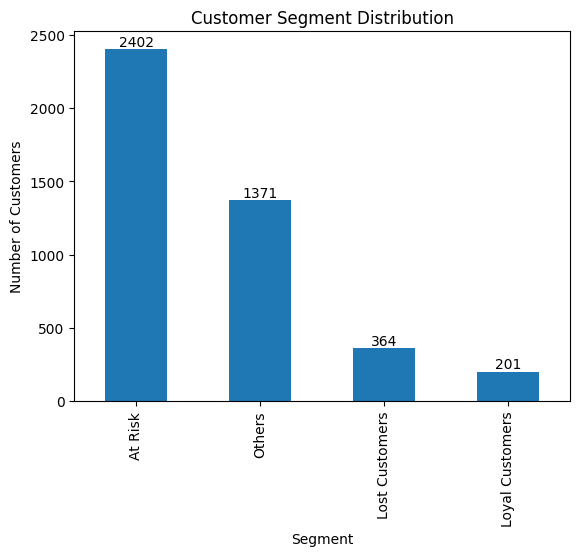

In [34]:
# visualize segment distribution
#count how many customers in each segment and convert counts into bar chart
ax = rfm['Segment'].value_counts().plot(kind='bar')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2, # center of bar
        bar.get_height(), # top of bar
        int(bar.get_height()), # value
        ha='center', va='bottom'
    )
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

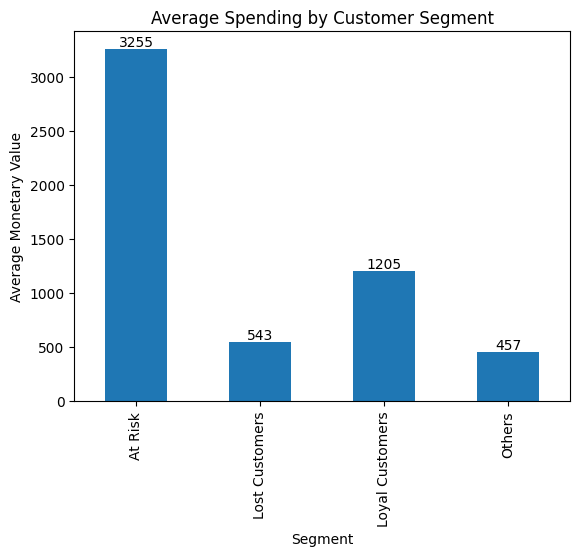

In [35]:
# average mmonetary by segment
# calculate average spending  per segment
Ax = rfm.groupby('Segment')['Monetary'].mean().plot(kind = 'bar')
for bar in Ax.patches:
    Ax.text(
        bar.get_x() + bar.get_width()/2, # center of bar
        bar.get_height(), # top of bar
        int(bar.get_height()), # value
        ha='center', va='bottom'
    )
plt.title('Average Spending by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value')
plt.show()

In [36]:
# Insights from Customer Segmentation

# 1. Most customers belong to the 'At Risk' segment,
# indicating many customers are becoming inactive.

# 2. A large number of customers fall under 'Others',
# showing average purchasing behavior.

# 3. The presence of 'Lost Customers' indicates some customers
# have completely stopped purchasing.

# 4. 'Loyal Customers' are very few,
# which shows low customer retention.

# 5. The business should focus on re-engaging 'At Risk' customers
# and converting them into loyal customers.

In [37]:
# export final rfm dataset to csv file
rfm.to_csv('RFM_Final_Output.csv',index = True)